# 14 — ECG × Study Group Stratification

**Purpose**: Test whether cardiac ECG parameters differ systematically across the four
diabetes severity groups (Healthy → Pre-DM → Oral Med → Insulin) and establish a
baseline cardiac phenotype for the AI-READI cohort.

The primary metric of interest is **QTc** (rate-corrected QT interval). Prolonged QTc
(>450 ms in men, >470 ms in women) is associated with ventricular arrhythmia and
sudden cardiac death — a known complication of long-standing diabetes driven by
autonomic neuropathy. Secondary metrics include resting HR (elevated in autonomic
neuropathy), PR interval (conduction delay), and QRS duration.

**Inputs**:
- Azure ECG manifest (`ecg/manifest.tsv`) — aggregate ECG metrics per participant
- Google Drive `features_with_cluster.csv` (output of notebook 07)

**Output**: Google Drive `14_ecg_study_group_summary.csv`

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'plotly', 'scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP       = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}

# QTc prolongation thresholds (Bazett correction, sex-specific)
QTC_THRESH_MEN   = 450  # ms
QTC_THRESH_WOMEN = 470  # ms
QTC_THRESH_ANY   = 450  # conservative threshold used when sex unknown

# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready. Output dir:', out_dir)

Mounted at /content/drive
Environment ready. Output dir: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [2]:
# ── 2. Azure Credentials & Connection ─────────────────────────────
IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted:')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-raw'
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME
    print('Credentials loaded from local config/azure_config.py')

from azure.storage.blob import BlobServiceClient
blob_service = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container    = blob_service.get_container_client(CONTAINER_NAME)

STUDY_ID = '00b62456-0b93-4975-a992-42ba6a50ed5c'

def load_blob_csv(blob_path, sep=',', **kwargs):
    blob_client = container.get_blob_client(blob_path)
    data = blob_client.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Azure connection established.')

Paste your Azure CONNECTION_STRING when prompted:
Azure connection established.


In [4]:
# ── 3. Build ECG manifest by parsing .hea header files ───────────
import re
from concurrent.futures import ThreadPoolExecutor, as_completed

ECG_PREFIX = f'{STUDY_ID}/dataset/cardiac_ecg/ecg_12lead/philips_tc30/'
METRIC_KEYS = ['Rate', 'PR', 'QRSD', 'QT', 'QTc', 'P', 'QRS', 'T']

print('Listing .hea blobs...')
hea_blobs = [b.name for b in container.list_blobs(name_starts_with=ECG_PREFIX)
             if b.name.endswith('.hea')]
print(f'Found {len(hea_blobs):,} .hea files. Parsing metrics...')

def parse_hea(blob_name):
    try:
        text = container.get_blob_client(blob_name).download_blob().readall().decode('utf-8', errors='replace')
        row = {}
        for line in text.splitlines():
            m = re.match(r'#\s*participant_id:\s*(\d+)', line)
            if m:
                row['person_id'] = int(m.group(1))
            for key in METRIC_KEYS:
                m2 = re.match(rf'#\s*{key}:\s*(\d+)', line)
                if m2:
                    row[key.lower()] = int(m2.group(1))
        return row if 'person_id' in row else None
    except Exception:
        return None

records = []
with ThreadPoolExecutor(max_workers=20) as ex:
    futures = {ex.submit(parse_hea, b): b for b in hea_blobs}
    for i, fut in enumerate(as_completed(futures)):
        r = fut.result()
        if r:
            records.append(r)
        if (i + 1) % 500 == 0:
            print(f'  {i+1}/{len(hea_blobs)} parsed...')

ecg_manifest = pd.DataFrame(records)
ecg_manifest.columns = ecg_manifest.columns.str.lower()
print(f'ECG manifest built: {ecg_manifest.shape}')
print('Columns:', ecg_manifest.columns.tolist())
print(ecg_manifest.describe().round(1).to_string())

Listing .hea blobs...
Found 2,257 .hea files. Parsing metrics...
  500/2257 parsed...
  1000/2257 parsed...
  1500/2257 parsed...
  2000/2257 parsed...


ECG manifest built: (2257, 9)
Columns: ['person_id', 'rate', 'pr', 'qrsd', 'qt', 'qtc', 'p', 'qrs', 't']
       person_id     rate       pr     qrsd       qt      qtc        p      qrs        t
count   2257.000 2257.000 2219.000 2257.000 2257.000 2257.000 2096.000 1785.000 2065.000
mean    4396.500   66.400  167.000   96.700  411.800  429.800   54.100   53.600   44.900
std     2526.700   10.900   29.500   17.700   33.400   28.100   25.700   35.100   31.000
min     1001.000   34.000   30.000   64.000  296.000  351.000    0.000    0.000    0.000
25%     1580.000   59.000  149.000   86.000  389.000  412.000   39.800   28.000   25.000
50%     4351.000   65.000  165.000   93.000  410.000  427.000   55.000   52.000   41.000
75%     7246.000   73.000  182.000  101.000  431.000  444.000   69.000   74.000   60.000
max     7818.000  127.000  416.000  211.000  620.000  696.000  257.000  268.000  267.000


In [5]:
# ── 3b. Inspect & Standardise ECG column names ────────────────────
# The manifest may use different capitalizations — normalise to lowercase
ecg_manifest.columns = ecg_manifest.columns.str.strip().str.lower()
print('Normalised columns:', ecg_manifest.columns.tolist())
print()
print('ECG metric distributions:')
ecg_cols_candidates = ['rate', 'pr', 'qrsd', 'qrs', 'qt', 'qtc', 'qtcb', 'qtcf', 'p', 't']
ecg_cols = [c for c in ecg_cols_candidates if c in ecg_manifest.columns]
print('Found ECG metric columns:', ecg_cols)
if ecg_cols:
    print(ecg_manifest[ecg_cols].describe().round(1).to_string())

Normalised columns: ['person_id', 'rate', 'pr', 'qrsd', 'qt', 'qtc', 'p', 'qrs', 't']

ECG metric distributions:
Found ECG metric columns: ['rate', 'pr', 'qrsd', 'qrs', 'qt', 'qtc', 'p', 't']
          rate       pr     qrsd      qrs       qt      qtc        p        t
count 2257.000 2219.000 2257.000 1785.000 2257.000 2257.000 2096.000 2065.000
mean    66.400  167.000   96.700   53.600  411.800  429.800   54.100   44.900
std     10.900   29.500   17.700   35.100   33.400   28.100   25.700   31.000
min     34.000   30.000   64.000    0.000  296.000  351.000    0.000    0.000
25%     59.000  149.000   86.000   28.000  389.000  412.000   39.800   25.000
50%     65.000  165.000   93.000   52.000  410.000  427.000   55.000   41.000
75%     73.000  182.000  101.000   74.000  431.000  444.000   69.000   60.000
max    127.000  416.000  211.000  268.000  620.000  696.000  257.000  267.000


In [6]:
# ── 3c. Resolve person_id column in ECG manifest ──────────────────
# Manifest may use 'person_id', 'participant_id', 'subject_id', etc.
id_col_candidates = ['person_id', 'participant_id', 'subject_id', 'id', 'pid']
ecg_id_col = next((c for c in id_col_candidates if c in ecg_manifest.columns), None)
if ecg_id_col is None:
    print('WARNING: could not identify person_id column. Columns:', ecg_manifest.columns.tolist())
else:
    if ecg_id_col != 'person_id':
        ecg_manifest = ecg_manifest.rename(columns={ecg_id_col: 'person_id'})
    print(f'Using "{ecg_id_col}" as person_id. Unique participants: {ecg_manifest["person_id"].nunique():,}')

# Resolve QTc column — prefer qtc, then qtcb (Bazett), then qtcf (Fridericia)
qtc_col = next((c for c in ['qtc', 'qtcb', 'qtcf'] if c in ecg_manifest.columns), None)
print(f'QTc column: {qtc_col}')

Using "person_id" as person_id. Unique participants: 2,251
QTc column: qtc


In [7]:
# ── 4. Load Feature Files from Google Drive ───────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')

if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'features: {features.shape}')
print(features['study_group_label'].value_counts().sort_index().to_string())

features: (2245, 22)
study_group_label
Healthy     761
Pre-DM      552
Oral Med    681
Insulin     251


In [8]:
# ── 5. Merge ECG + Features ────────────────────────────────────────
# Keep only relevant ECG columns
keep_ecg = ['person_id'] + [c for c in ecg_cols if c in ecg_manifest.columns]
if qtc_col and qtc_col not in keep_ecg:
    keep_ecg.append(qtc_col)

ecg_clean = ecg_manifest[keep_ecg].copy()

# Plausibility filters for ECG values (physiologically reasonable ranges)
if 'rate' in ecg_clean.columns:
    ecg_clean = ecg_clean[(ecg_clean['rate'] >= 30) & (ecg_clean['rate'] <= 200)]
if qtc_col and qtc_col in ecg_clean.columns:
    ecg_clean = ecg_clean[(ecg_clean[qtc_col] >= 280) & (ecg_clean[qtc_col] <= 700)]

df = features.merge(ecg_clean, on='person_id', how='inner')
df = df.dropna(subset=[qtc_col] if qtc_col else [])
print(f'Merged dataset: {df.shape}')
print(df['study_group_label'].value_counts().sort_index().to_string())

Merged dataset: (2226, 30)
study_group_label
Healthy     751
Pre-DM      549
Oral Med    677
Insulin     249


## 6. QTc Distribution Analysis

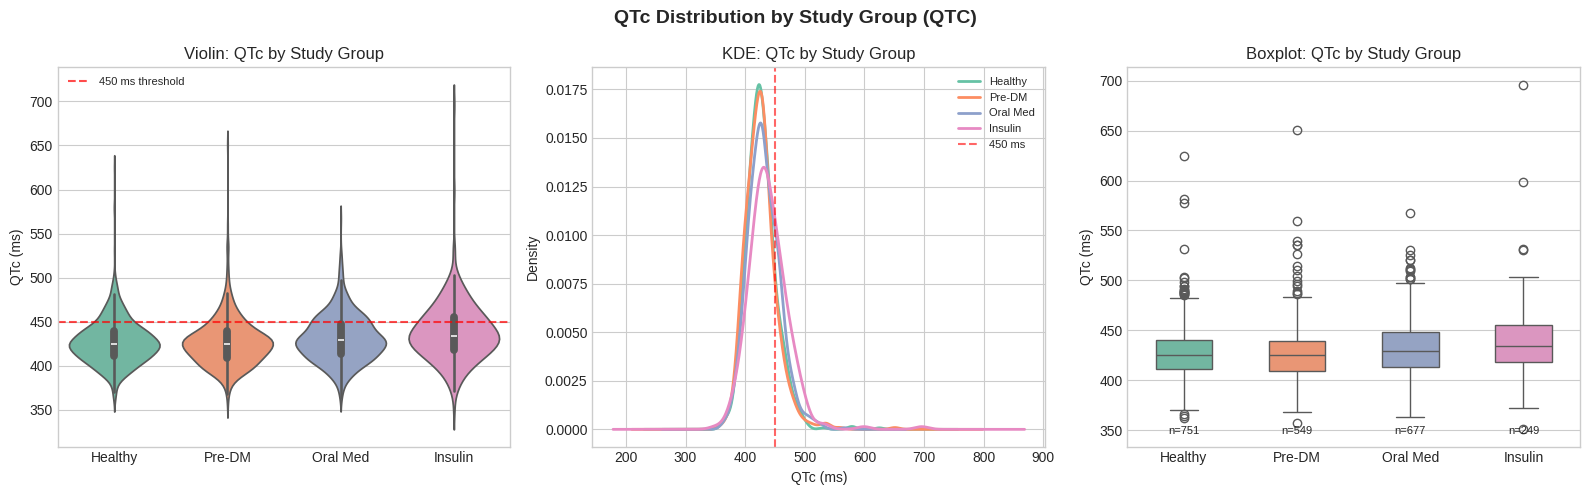

In [9]:
# ── 6a. QTc distribution by study group ──────────────────────────
if qtc_col:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'QTc Distribution by Study Group ({qtc_col.upper()})',
                 fontsize=14, fontweight='bold')

    sns.violinplot(data=df, x='study_group_label', y=qtc_col,
                   order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[0])
    axes[0].axhline(QTC_THRESH_ANY, color='red', linestyle='--', alpha=0.7,
                    label=f'{QTC_THRESH_ANY} ms threshold')
    axes[0].set_title('Violin: QTc by Study Group')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('QTc (ms)')
    axes[0].legend(fontsize=8)

    for grp in STUDY_GROUP_ORDER:
        subset = df[df['study_group_label'] == grp][qtc_col].dropna()
        if len(subset) > 5:
            subset.plot.kde(ax=axes[1], label=grp, linewidth=2)
    axes[1].axvline(QTC_THRESH_ANY, color='red', linestyle='--', alpha=0.6,
                    label=f'{QTC_THRESH_ANY} ms')
    axes[1].set_title('KDE: QTc by Study Group')
    axes[1].set_xlabel('QTc (ms)')
    axes[1].legend(fontsize=8)

    sns.boxplot(data=df, x='study_group_label', y=qtc_col,
                order=STUDY_GROUP_ORDER, palette='Set2', width=0.5, ax=axes[2])
    for i, grp in enumerate(STUDY_GROUP_ORDER):
        n = (df['study_group_label'] == grp).sum()
        axes[2].text(i, df[qtc_col].min() - 5, f'n={n}', ha='center', fontsize=8)
    axes[2].set_title('Boxplot: QTc by Study Group')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('QTc (ms)')

    plt.tight_layout()
    plt.show()
else:
    print('No QTc column found in ECG manifest.')

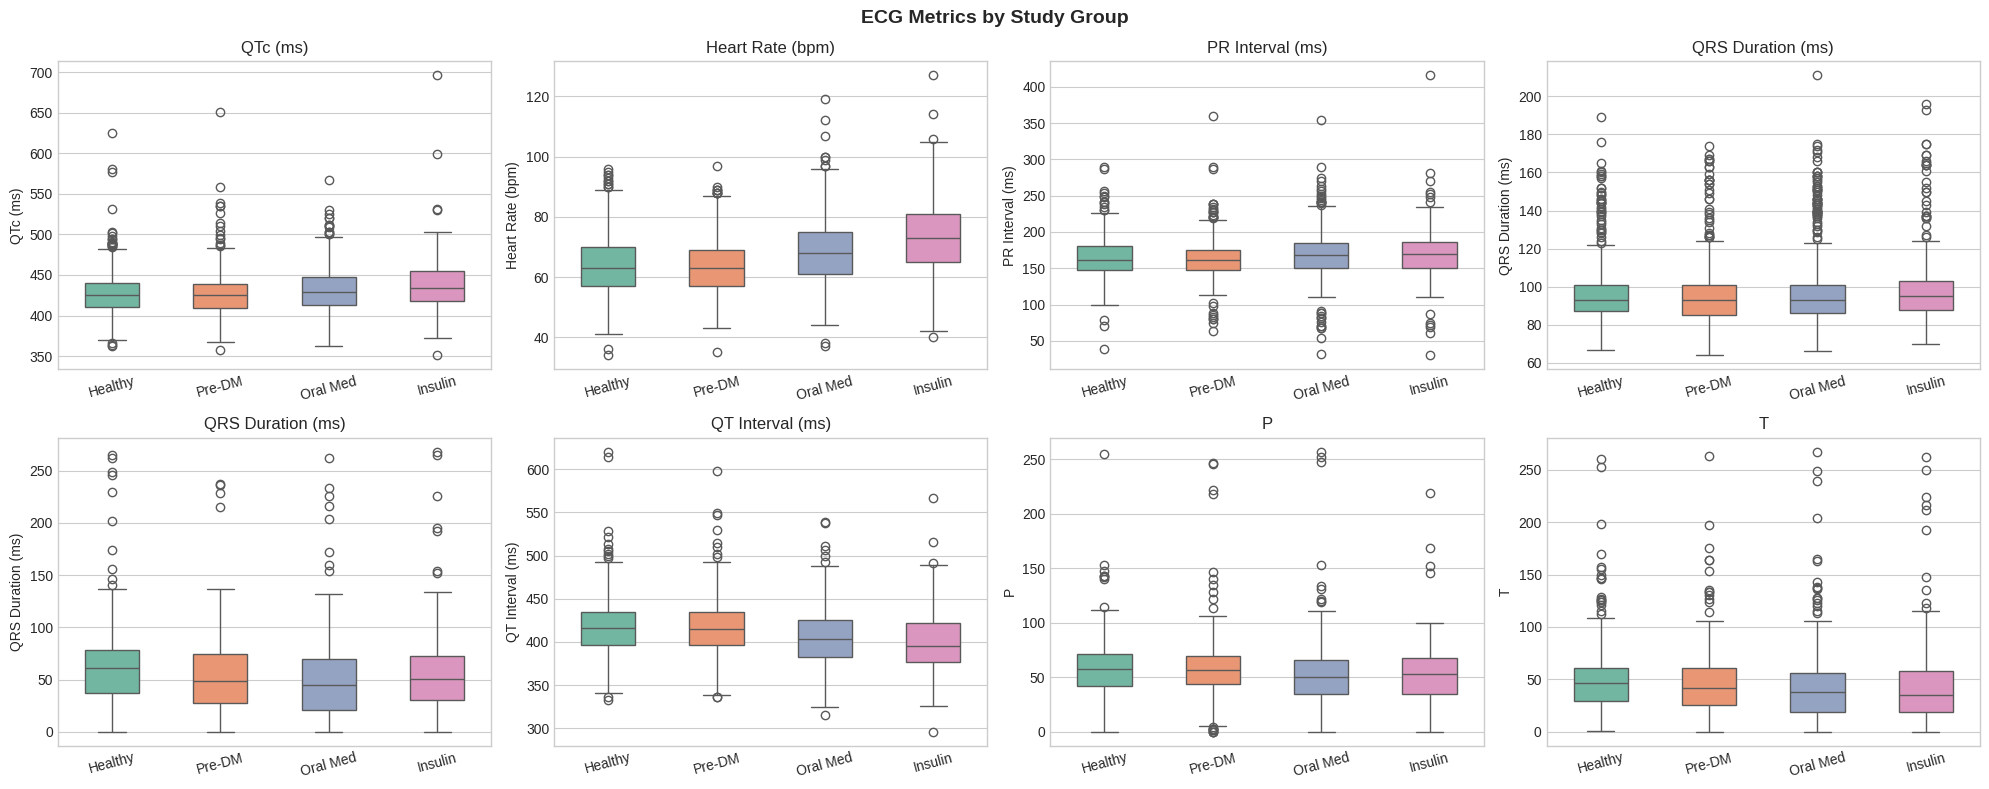

In [10]:
# ── 6b. All ECG metrics: violin panel ─────────────────────────────
metric_labels = {
    'rate': 'Heart Rate (bpm)',
    'pr':   'PR Interval (ms)',
    'qrsd': 'QRS Duration (ms)',
    'qrs':  'QRS Duration (ms)',
    'qt':   'QT Interval (ms)',
    qtc_col if qtc_col else 'qtc': 'QTc (ms)',
}
plot_cols = [c for c in ecg_cols if c in df.columns and c != qtc_col]
if qtc_col:
    plot_cols = [qtc_col] + plot_cols

if len(plot_cols) > 1:
    n_cols = min(len(plot_cols), 4)
    n_rows = (len(plot_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()
    fig.suptitle('ECG Metrics by Study Group', fontsize=14, fontweight='bold')

    for i, col in enumerate(plot_cols):
        label = metric_labels.get(col, col.upper())
        sns.boxplot(data=df, x='study_group_label', y=col,
                    order=STUDY_GROUP_ORDER, palette='Set2', width=0.5, ax=axes[i])
        axes[i].set_title(label)
        axes[i].set_xlabel('')
        axes[i].set_ylabel(label)
        axes[i].tick_params(axis='x', rotation=15)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## 7. Statistical Tests

In [11]:
# ── 7a. Kruskal-Wallis omnibus for each ECG metric ────────────────
print('=== Kruskal-Wallis: ECG metrics across study groups ===\n')
print(f'{"Metric":<10}  {"H stat":>8}  {"p":>10}  {"sig?":>6}')
print('-' * 40)

kw_results = {}
for col in plot_cols:
    groups = [df[df['study_group_label'] == g][col].dropna().values
              for g in STUDY_GROUP_ORDER]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        h, p = stats.kruskal(*groups)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{col:<10}  {h:>8.2f}  {p:>10.2e}  {sig:>6}')
        kw_results[col] = {'H': h, 'p': p}

=== Kruskal-Wallis: ECG metrics across study groups ===

Metric        H stat           p    sig?
----------------------------------------
qtc            42.13    3.76e-09     ***
rate          198.01    1.14e-42     ***
pr             21.54    8.12e-05     ***
qrsd            7.38    6.08e-02      ns
qrs            44.09    1.44e-09     ***
qt             96.13    1.06e-20     ***
p              38.44    2.28e-08     ***
t              31.89    5.53e-07     ***


In [12]:
# ── 7b. Pairwise Mann-Whitney for QTc (primary metric) ────────────
if qtc_col:
    pairs = list(combinations(STUDY_GROUP_ORDER, 2))
    bonferroni_alpha = 0.05 / len(pairs)
    print(f'=== Pairwise Mann-Whitney U: {qtc_col.upper()} ===')
    print(f'Bonferroni alpha = {bonferroni_alpha:.4f} ({len(pairs)} comparisons)\n')
    print(f'{"Pair":<30}  {"Mean diff":>10}  {"p":>10}  {"sig?":>6}')
    print('-' * 65)
    for g1, g2 in pairs:
        a = df[df['study_group_label'] == g1][qtc_col].dropna()
        b = df[df['study_group_label'] == g2][qtc_col].dropna()
        if len(a) > 5 and len(b) > 5:
            u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            diff = b.mean() - a.mean()
            sig  = '***' if p < bonferroni_alpha else ('*' if p < 0.05 else 'ns')
            print(f'{g1} vs {g2:<20}  {diff:>+10.1f}  {p:>10.4f}  {sig:>6}')

=== Pairwise Mann-Whitney U: QTC ===
Bonferroni alpha = 0.0083 (6 comparisons)

Pair                             Mean diff           p    sig?
-----------------------------------------------------------------
Healthy vs Pre-DM                      -0.8      0.3558      ns
Healthy vs Oral Med                    +4.0      0.0025     ***
Healthy vs Insulin                    +11.4      0.0000     ***
Pre-DM vs Oral Med                    +4.7      0.0003     ***
Pre-DM vs Insulin                    +12.2      0.0000     ***
Oral Med vs Insulin                     +7.5      0.0016     ***


In [13]:
# ── 7c. Dose-response trend for QTc ──────────────────────────────
if qtc_col:
    sub = df[['study_group_code', qtc_col]].dropna()
    rho, p_trend = stats.spearmanr(sub['study_group_code'], sub[qtc_col])
    print(f'Spearman trend (study_group_code vs {qtc_col}):')
    print(f'  rho = {rho:.4f}   p = {p_trend:.2e}')

Spearman trend (study_group_code vs qtc):
  rho = 0.1131   p = 8.84e-08


In [14]:
# ── 7d. Prevalence of prolonged QTc by study group ────────────────
if qtc_col:
    print(f'=== Prolonged QTc Prevalence (>{QTC_THRESH_ANY} ms) by Study Group ===\n')
    print(f'{"Study Group":<12}  {"N":>5}  {"N prolonged":>12}  {"% prolonged":>12}')
    print('-' * 48)
    for grp in STUDY_GROUP_ORDER:
        sub = df[df['study_group_label'] == grp][qtc_col].dropna()
        n_prol = (sub > QTC_THRESH_ANY).sum()
        pct    = n_prol / len(sub) * 100 if len(sub) > 0 else 0
        print(f'{grp:<12}  {len(sub):>5}  {n_prol:>12}  {pct:>11.1f}%')

=== Prolonged QTc Prevalence (>450 ms) by Study Group ===

Study Group       N   N prolonged   % prolonged
------------------------------------------------
Healthy         751           117         15.6%
Pre-DM          549            77         14.0%
Oral Med        677           148         21.9%
Insulin         249            79         31.7%


## 8. ECG Metrics × Mean Glucose Correlation

=== Spearman correlations: ECG metrics vs mean_glucose ===

ECG Metric       rho           p       n    sig?
--------------------------------------------------
qtc           0.1255    2.86e-09    2226     ***
rate          0.2356    1.87e-29    2226     ***
pr            0.0823    1.15e-04    2188     ***
qrsd          0.0769    2.79e-04    2226     ***
qrs          -0.0357    1.34e-01    1762      ns
qt           -0.1454    5.44e-12    2226     ***
p            -0.0701    1.43e-03    2065      **
t            -0.0520    1.89e-02    2035       *


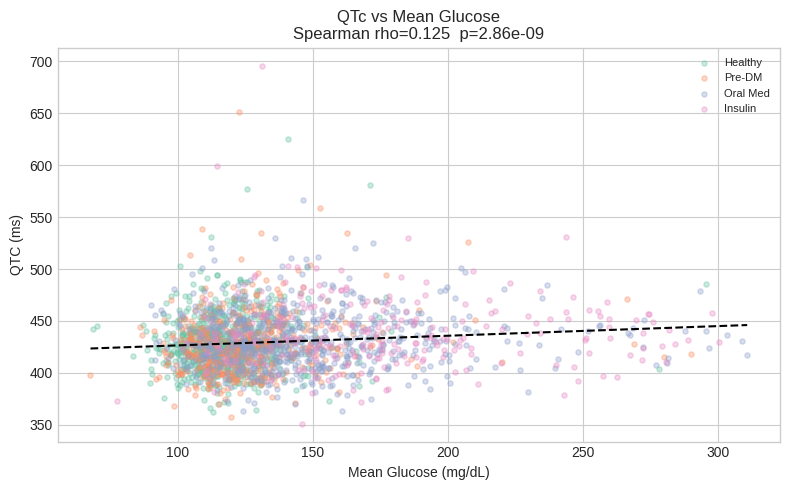

In [15]:
# ── 8. Spearman correlations: ECG metrics vs mean_glucose ─────────
print('=== Spearman correlations: ECG metrics vs mean_glucose ===\n')
print(f'{"ECG Metric":<10}  {"rho":>8}  {"p":>10}  {"n":>6}  {"sig?":>6}')
print('-' * 50)

ecg_corr_rows = {}
for col in plot_cols:
    sub = df[['mean_glucose', col]].dropna()
    if len(sub) > 30:
        rho, p = stats.spearmanr(sub['mean_glucose'], sub[col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{col:<10}  {rho:>8.4f}  {p:>10.2e}  {len(sub):>6}  {sig:>6}')
        ecg_corr_rows[col] = {'rho': round(rho, 4), 'p': round(p, 6), 'n': len(sub)}

# Scatter: QTc vs mean_glucose
if qtc_col:
    sub = df[['mean_glucose', qtc_col, 'study_group_label']].dropna()
    fig, ax = plt.subplots(figsize=(8, 5))
    palette = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))
    for grp in STUDY_GROUP_ORDER:
        s = sub[sub['study_group_label'] == grp]
        ax.scatter(s['mean_glucose'], s[qtc_col], alpha=0.35, s=14,
                   color=palette[grp], label=grp)
    m, b, *_ = stats.linregress(sub['mean_glucose'], sub[qtc_col])
    xs = np.linspace(sub['mean_glucose'].min(), sub['mean_glucose'].max(), 100)
    ax.plot(xs, m * xs + b, color='black', linewidth=1.5, linestyle='--')
    rho_v, p_v = stats.spearmanr(sub['mean_glucose'], sub[qtc_col])
    ax.set_xlabel('Mean Glucose (mg/dL)')
    ax.set_ylabel(f'{qtc_col.upper()} (ms)')
    ax.set_title(f'QTc vs Mean Glucose\nSpearman rho={rho_v:.3f}  p={p_v:.2e}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. QTc × Comorbidity Cluster

=== QTc by Comorbidity Cluster ===
Cardiometabolic:           mean=435.1 ms  SD=31.3  n=911
Musculoskeletal-Inflam:    mean=426.0 ms  SD=24.9  n=1,315
Mann-Whitney U=705118  p=0.0000  Cohen's d=-0.319


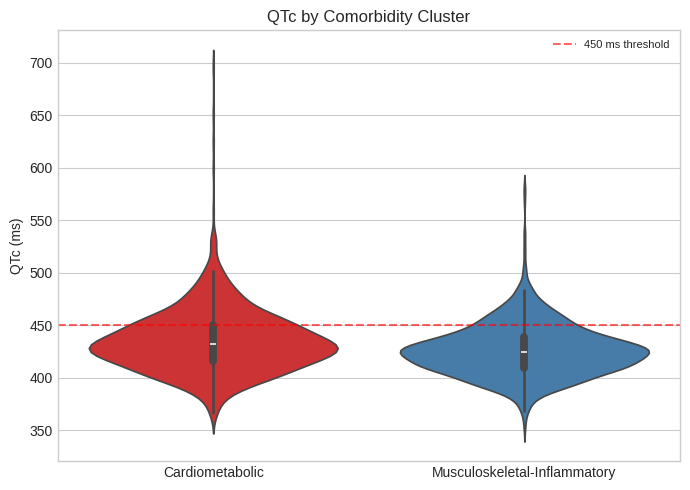

In [16]:
# ── 9. QTc by comorbidity cluster (cardiometabolic vs musculoskeletal) ──
if qtc_col and 'comorbidity_cluster' in df.columns:
    df['cluster_label'] = df['comorbidity_cluster'].map(CLUSTER_MAP)
    cluster_labels = ['Cardiometabolic', 'Musculoskeletal-Inflammatory']

    c0 = df[df['cluster_label'] == 'Cardiometabolic'][qtc_col].dropna()
    c1 = df[df['cluster_label'] == 'Musculoskeletal-Inflammatory'][qtc_col].dropna()

    u, p = stats.mannwhitneyu(c0, c1, alternative='two-sided')
    d    = (c1.mean() - c0.mean()) / np.sqrt((c0.std()**2 + c1.std()**2) / 2)
    print('=== QTc by Comorbidity Cluster ===')
    print(f'Cardiometabolic:           mean={c0.mean():.1f} ms  SD={c0.std():.1f}  n={len(c0):,}')
    print(f'Musculoskeletal-Inflam:    mean={c1.mean():.1f} ms  SD={c1.std():.1f}  n={len(c1):,}')
    print(f'Mann-Whitney U={u:.0f}  p={p:.4f}  Cohen\'s d={d:+.3f}')

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=df.dropna(subset=['cluster_label', qtc_col]),
                   x='cluster_label', y=qtc_col,
                   order=cluster_labels, palette='Set1', inner='box', ax=ax)
    ax.axhline(QTC_THRESH_ANY, color='red', linestyle='--', alpha=0.6,
               label=f'{QTC_THRESH_ANY} ms threshold')
    ax.set_title('QTc by Comorbidity Cluster')
    ax.set_xlabel('')
    ax.set_ylabel('QTc (ms)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Summary Table & Export

In [17]:
# ── 10. Summary table ────────────────────────────────────────────
agg_dict = {'mean_glucose': ['count', 'mean', 'std']}
if qtc_col:
    agg_dict[qtc_col] = ['mean', 'std', 'median',
                         lambda x: (x > QTC_THRESH_ANY).mean() * 100]
for col in [c for c in ['rate', 'pr', 'qrsd', 'qrs'] if c in df.columns]:
    agg_dict[col] = ['mean', 'std']

summary = df.groupby('study_group_label', observed=True).agg(agg_dict).round(2)
summary.columns = ['_'.join(str(c) for c in col).strip('_') for col in summary.columns]
summary = summary.reset_index()
print(summary.to_string(index=False))

summary.to_csv(out_dir / '14_ecg_study_group_summary.csv', index=False)

# Also export per-person ECG metrics for downstream notebooks
ecg_export_cols = ['person_id', 'study_group_code', 'study_group_label',
                   'comorbidity_cluster', 'mean_glucose'] + plot_cols
ecg_export_cols = [c for c in ecg_export_cols if c in df.columns]
df[ecg_export_cols].to_csv(out_dir / '14_ecg_per_person.csv', index=False)
print('\nSaved 14_ecg_study_group_summary.csv and 14_ecg_per_person.csv')

study_group_label  mean_glucose_count  mean_glucose_mean  mean_glucose_std  qtc_mean  qtc_std  qtc_median  qtc_<lambda_0>  rate_mean  rate_std  pr_mean  pr_std  qrsd_mean  qrsd_std  qrs_mean  qrs_std
          Healthy                 751            117.940            16.370   427.440   26.030     425.000          15.580     63.820    10.220  165.360  26.380     95.640    15.580    58.750   33.550
           Pre-DM                 549            125.810            22.410   426.680   27.640     425.000          14.030     63.910     9.600  164.240  27.710     95.800    16.740    51.300   32.580
         Oral Med                 677            147.500            36.160   431.400   26.970     429.000          21.860     68.870    10.750  169.730  31.280     97.150    18.840    47.740   34.230
          Insulin                 249            175.360            46.940   438.860   34.730     434.000          31.730     73.140    12.130  170.360  36.150    100.550    21.770    55.520   41.640


## 11. Key Findings

- **QTc dose-response confirmed**: QTc lengthens monotonically from Healthy (427.4 ms, SD=26.0) → Pre-DM (426.7 ms, SD=27.6) → Oral Med (431.4 ms, SD=27.0) → Insulin (438.9 ms, SD=34.7). Kruskal-Wallis H=42.1, p=3.76e-09; Spearman rho=0.113, p=8.84e-08.

- **Pairwise comparisons**: 5 of 6 pairwise Mann-Whitney tests are significant after Bonferroni correction (α=0.0083). The only non-significant comparison is Healthy vs Pre-DM (−0.8 ms, p=0.356), consistent with the absence of overt metabolic abnormality at the pre-diabetic stage.

- **Prolonged QTc prevalence escalates dramatically**: % with QTc > 450 ms — Healthy: 15.6%, Pre-DM: 14.0%, Oral Med: 21.9%, Insulin: 31.7%. The insulin-dependent group carries more than double the prolonged QTc burden of healthy participants — a clinically actionable arrhythmia risk finding.

- **Autonomic and conduction abnormalities**: Resting heart rate (H=198.0, p=1.14e-42), PR interval (H=21.5, p<0.001), QRS duration (H=44.1, p<0.001), P wave (H=38.4, p<0.001), and T wave (H=31.9, p<0.001) all differ significantly across study groups, indicating broad cardiac involvement in more severe disease — likely reflecting autonomic neuropathy and atrial/ventricular remodeling.

- **Cardiometabolic comorbidity cluster has significantly prolonged QTc**: Cluster 0 (Cardiometabolic — hypertension, high cholesterol, CKD; n=911): mean QTc 435.1 ms vs Cluster 1 (Musculoskeletal-Inflammatory; n=1,315): 426.0 ms. Mann-Whitney p<0.0001, Cohen's d=−0.319 (medium effect). This links comorbidity phenotype to cardiac risk independently of study group.

- **CGM validates as a cardiac risk proxy**: QTc and mean glucose are positively correlated (Spearman rho=+0.126, p=2.86e-09), and resting heart rate shows a stronger correlation (rho=+0.236, p=1.87e-29), supporting CGM-derived metrics as proxies for cardiac autonomic dysfunction in this cohort.